In [1]:
import torch, torchvision
import torch.nn as nn, torch.optim as optim
from torchvision import transforms as T
from torch.utils.data import DataLoader, Subset
from matplotlib import pyplot as plt

t   = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trd = DataLoader(Subset(torchvision.datasets.CIFAR10('./data', True,  transform=t, download=True), range(2000)), 64, True)
ted = DataLoader(Subset(torchvision.datasets.CIFAR10('./data', False, transform=t, download=True),range(50)), 64)

Files already downloaded and verified
Files already downloaded and verified


In [2]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(4096,128), nn.ReLU(), nn.Linear(128,10)
        )
    def forward(self, x):
        return self.net(x)

def train(model, opt, crit, epochs=5):
    trl, tel, acl = [], [], []
    for e in range(epochs):
        model.train()
        rl = 0
        for x, y in trd:
            opt.zero_grad()
            o = model(x)
            l = crit(o, y)
            l.backward()
            opt.step()
            rl += l.item()
        model.eval()
        tl = 0
        c  = 0
        n  = 0
        with torch.no_grad():
            for x, y in ted:
                o = model(x)
                l = crit(o, y)
                tl += l.item()
                c  += (o.argmax(1)==y).sum().item()
                n  += len(y)
        trl.append(rl/len(trd))
        tel.append(tl/len(ted))
        acl.append(c/n)
        print(f'E{e+1} | Train {rl/len(trd):.4f} | Test {tl/len(ted):.4f} | Acc {c/n:.2f}')
    return trl, tel, acl

SGD
E1 | Train 2.2031 | Test 1.8274 | Acc 0.44
E2 | Train 1.9441 | Test 1.7769 | Acc 0.32
E3 | Train 1.7395 | Test 1.5384 | Acc 0.40
E4 | Train 1.5939 | Test 1.4993 | Acc 0.44
E5 | Train 1.4708 | Test 1.4212 | Acc 0.50
Adam
E1 | Train 1.9634 | Test 1.5636 | Acc 0.48
E2 | Train 1.5553 | Test 1.5656 | Acc 0.44
E3 | Train 1.3401 | Test 1.5337 | Acc 0.42
E4 | Train 1.2106 | Test 1.4753 | Acc 0.46
E5 | Train 0.9724 | Test 1.3829 | Acc 0.46


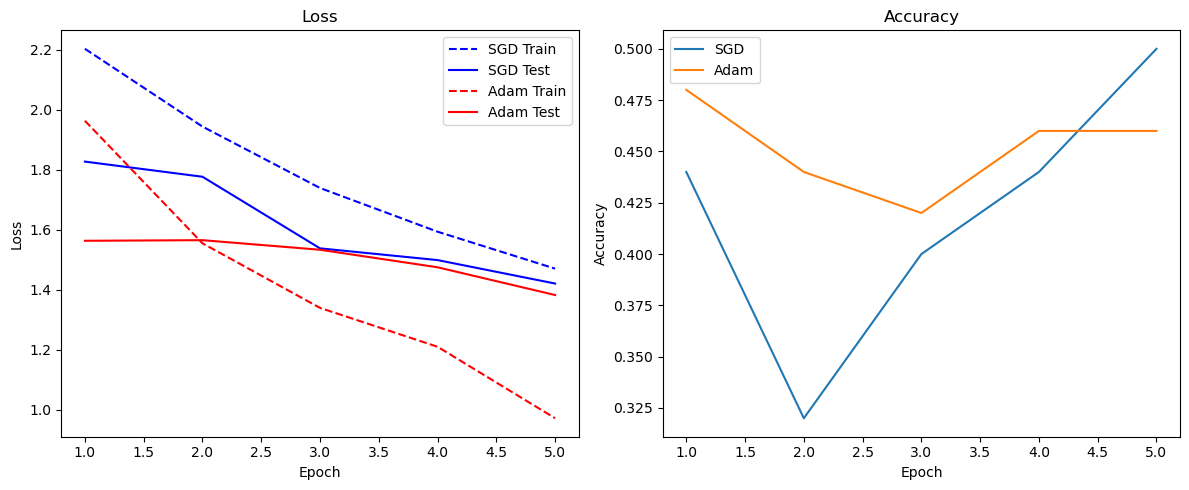

In [4]:
crit = nn.CrossEntropyLoss()
ms   = CNN()
ma   = CNN()
print('SGD')
trs, tes, acs = train(ms, optim.SGD(ms.parameters(), 0.01, momentum=0.9), crit)
print('Adam')
tra, tea, aca = train(ma, optim.Adam(ma.parameters(), 1e-3), crit)

ep = range(1, 6)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ep, trs, 'b--', label='SGD Train')
plt.plot(ep, tes, 'b-',  label='SGD Test')
plt.plot(ep, tra, 'r--', label='Adam Train')
plt.plot(ep, tea, 'r-',  label='Adam Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(ep, acs, label='SGD')
plt.plot(ep, aca, label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()